In [42]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

In [2]:
# Load the dataset
data = pd.read_csv('student_lifestyle_dataset.csv')

# Step 1: Overview of the dataset

In [3]:
print("Dataset Info:")
print(data.info())
print("\nSummary Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB
None

Summary Statistics:
        Student_ID  Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
count  2000.000000          2000.000000                    2000.000000   
mean   1000.500000    

# Step 2: Data Cleaning

In [4]:
# Check for missing values
missing_values = data.isnull().sum()
print("\nMissing Values:")
print(missing_values)


Missing Values:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64


In [6]:
# Check for duplicate rows
duplicate_rows = data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")



Number of duplicate rows: 0


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


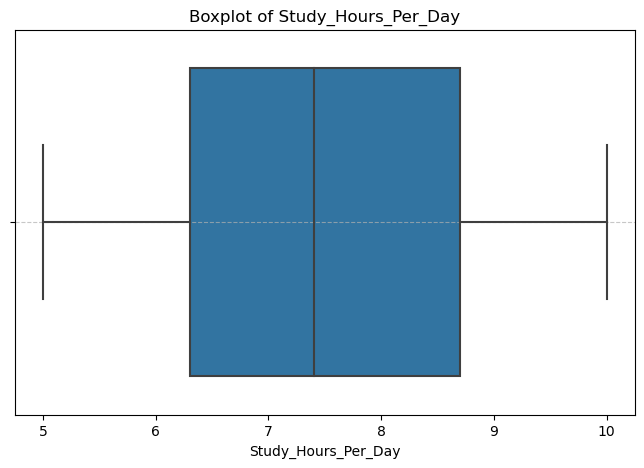

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


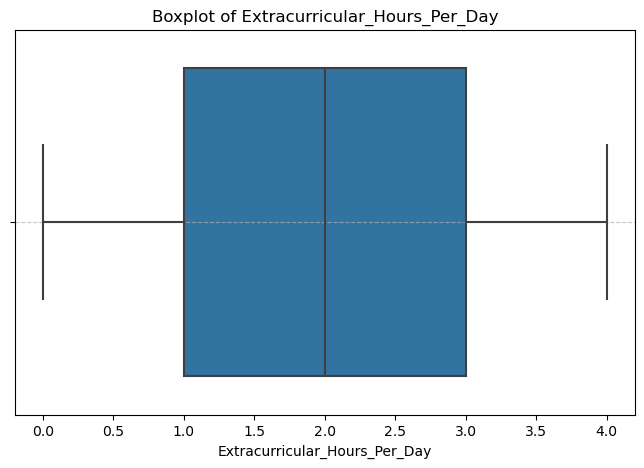

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


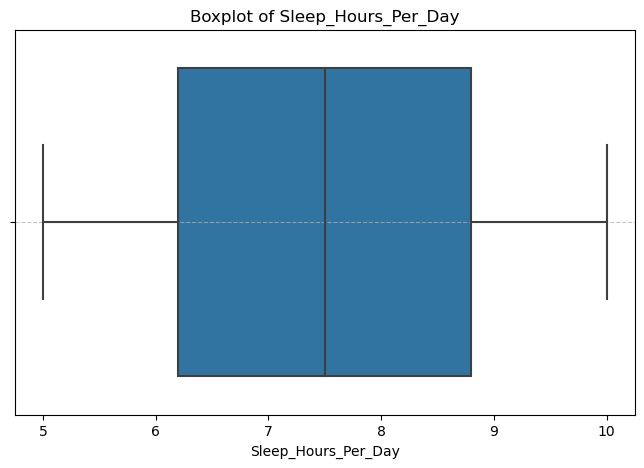

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


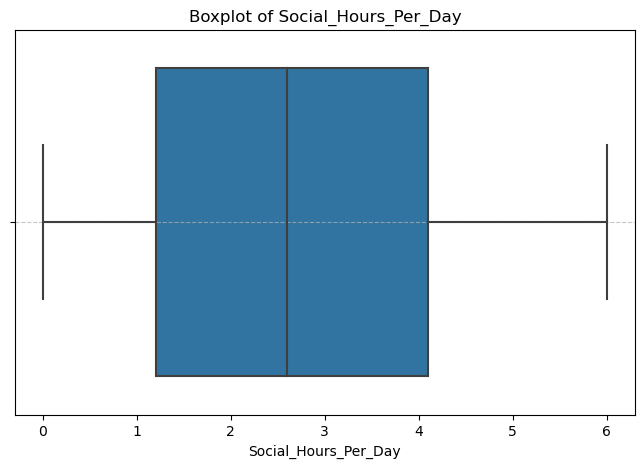

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


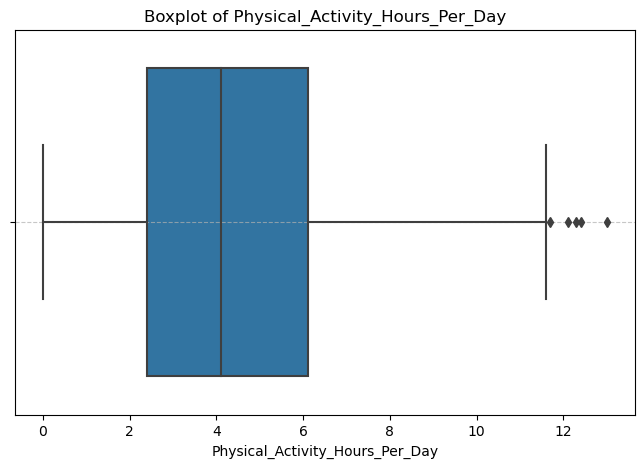

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


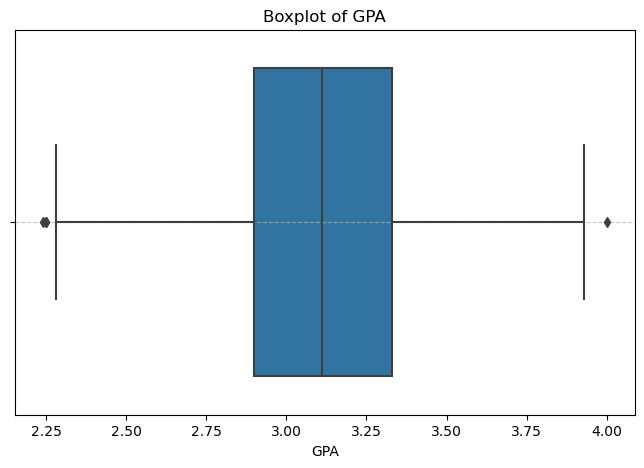

In [8]:
# Check for outliers (basic method: visual inspection or z-scores)
def plot_box(column, title):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data[column])
    plt.title(f'Boxplot of {title}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

columns_to_check_outliers = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day',
    'GPA'
]

for col in columns_to_check_outliers:
    plot_box(col, col)

In [9]:
# Optionally, handle outliers using techniques like capping or removal
# Example: Remove outliers beyond 1.5 IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in columns_to_check_outliers:
    data = remove_outliers(data, col)

print("\nOutliers have been removed from the dataset.")



Outliers have been removed from the dataset.


In [10]:
print("\nPost-Cleaning Dataset Info:")
print(data.info())
print("\nPost-Cleaning Summary Statistics:")
print(data.describe())


Post-Cleaning Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1991 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       1991 non-null   int64  
 1   Study_Hours_Per_Day              1991 non-null   float64
 2   Extracurricular_Hours_Per_Day    1991 non-null   float64
 3   Sleep_Hours_Per_Day              1991 non-null   float64
 4   Social_Hours_Per_Day             1991 non-null   float64
 5   Physical_Activity_Hours_Per_Day  1991 non-null   float64
 6   GPA                              1991 non-null   float64
 7   Stress_Level                     1991 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 140.0+ KB
None

Post-Cleaning Summary Statistics:
        Student_ID  Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
count  1991.000000          1991.000000                    1991.000

# Step 3: Plot distributions of numerical variables

In [12]:
def plot_distribution(data, column, title):
    """
    Plots the distribution of a given column from a dataset.

    Parameters:
    data (DataFrame): The dataset containing the column to plot.
    column (str): The column name for which the distribution will be plotted.
    title (str): The title of the plot.
    """
    plt.figure(figsize=(8, 5))
    plt.hist(data[column], bins=20, alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {title}')
    plt.xlabel(title)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

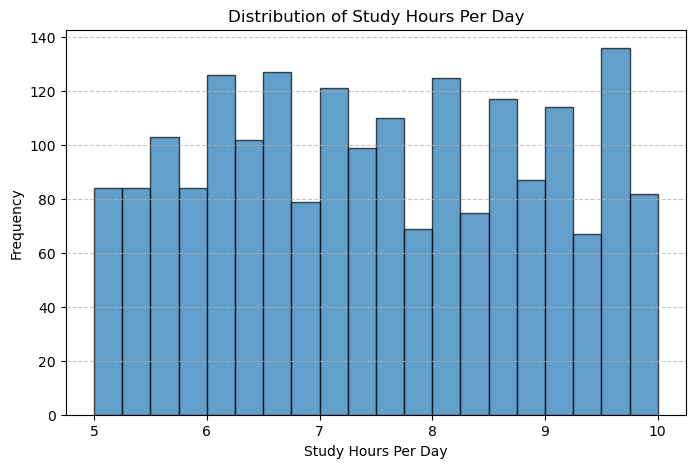

In [13]:
plot_distribution(data, 'Study_Hours_Per_Day', 'Study Hours Per Day')

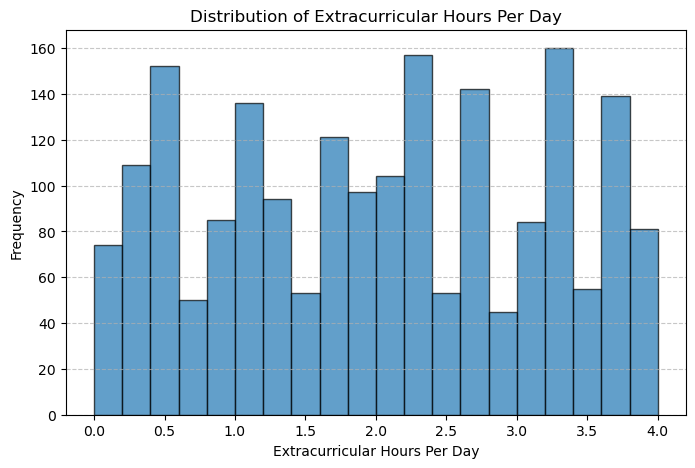

In [14]:
plot_distribution(data, 'Extracurricular_Hours_Per_Day', 'Extracurricular Hours Per Day')

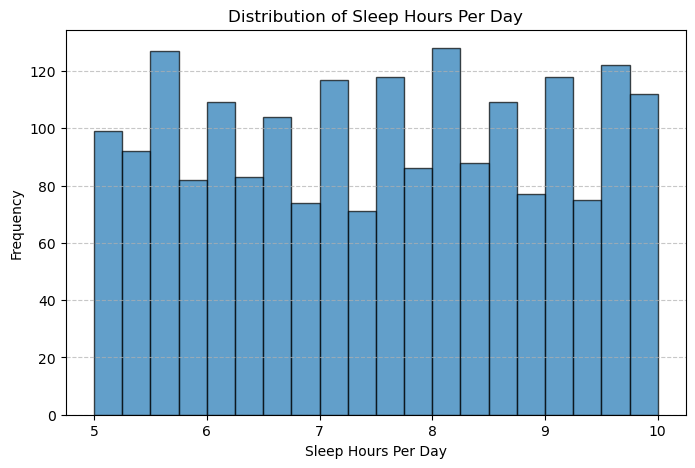

In [15]:
plot_distribution(data, 'Sleep_Hours_Per_Day', 'Sleep Hours Per Day')

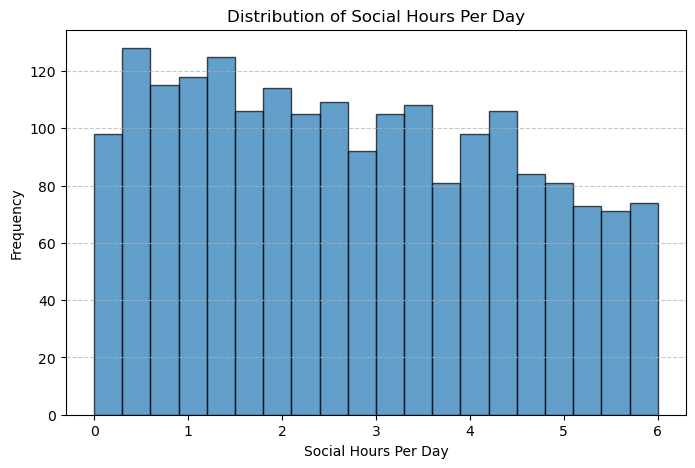

In [16]:
plot_distribution(data, 'Social_Hours_Per_Day', 'Social Hours Per Day')

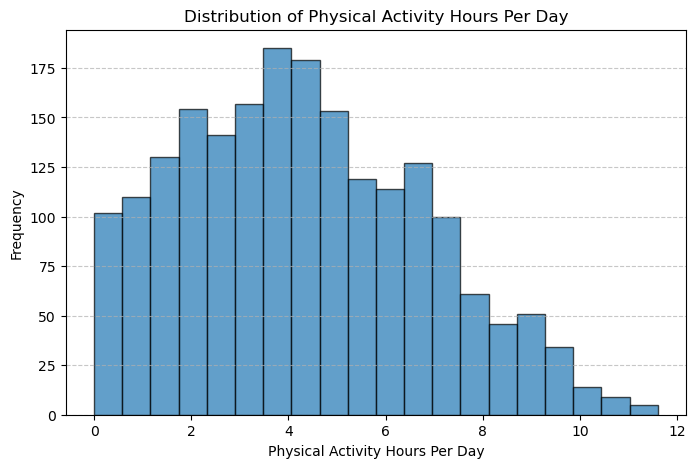

In [17]:
plot_distribution(data, 'Physical_Activity_Hours_Per_Day', 'Physical Activity Hours Per Day')

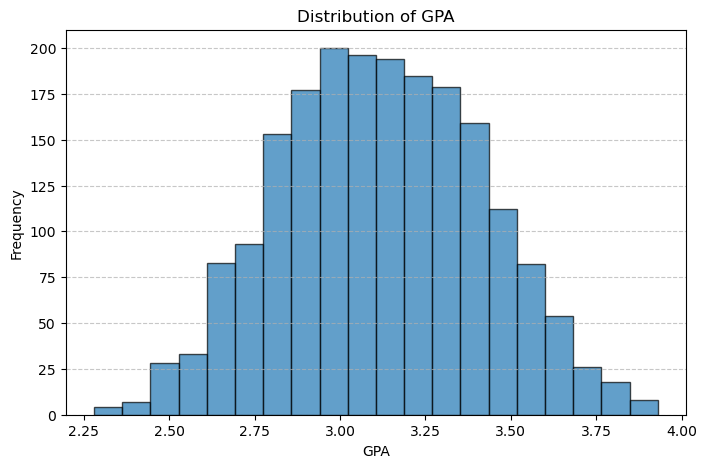

In [18]:
plot_distribution(data, 'GPA', 'GPA')

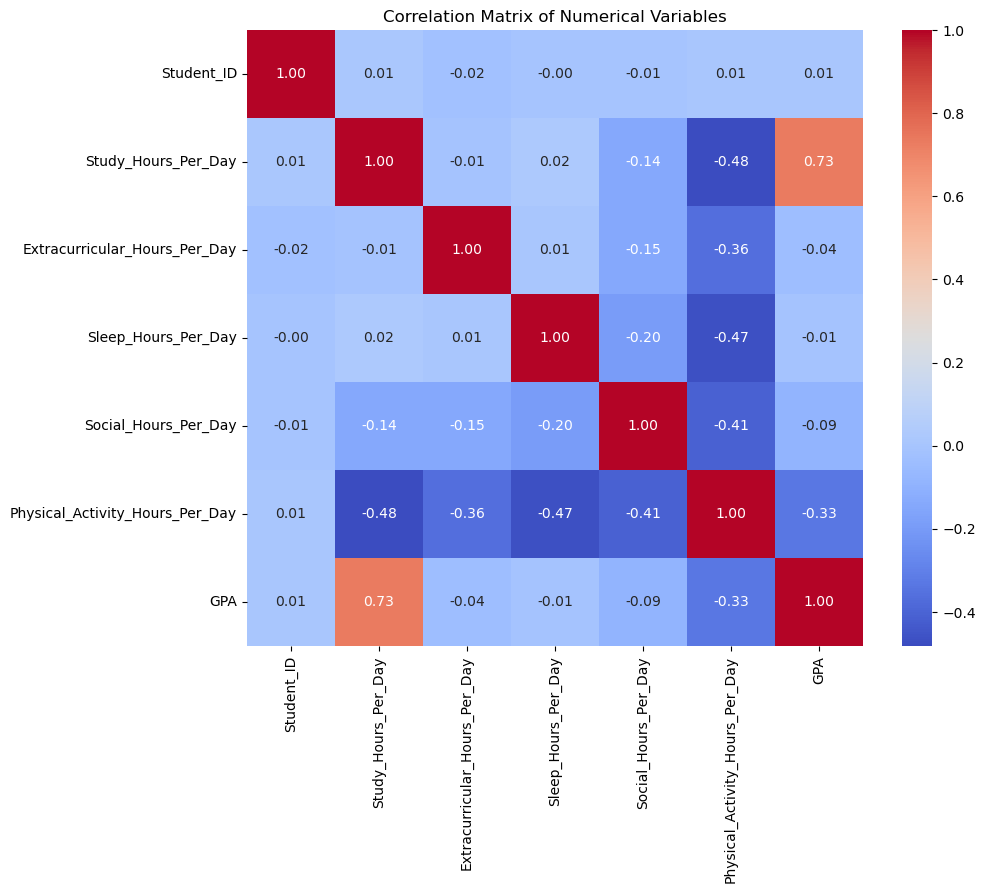

In [19]:
# Correlation analysis
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [20]:
def plot_relationship(data, x, y, title, xlabel, ylabel):
    """
    Plots the relationship between two variables in a dataset.

    Parameters:
    data (DataFrame): The dataset containing the columns.
    x (str): The column name for the x-axis.
    y (str): The column name for the y-axis.
    title (str): The title of the plot.
    xlabel (str): The label for the x-axis.
    ylabel (str): The label for the y-axis.
    """
    plt.figure(figsize=(8, 5))
    plt.scatter(data[x], data[y], alpha=0.5, edgecolor='k')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.show()

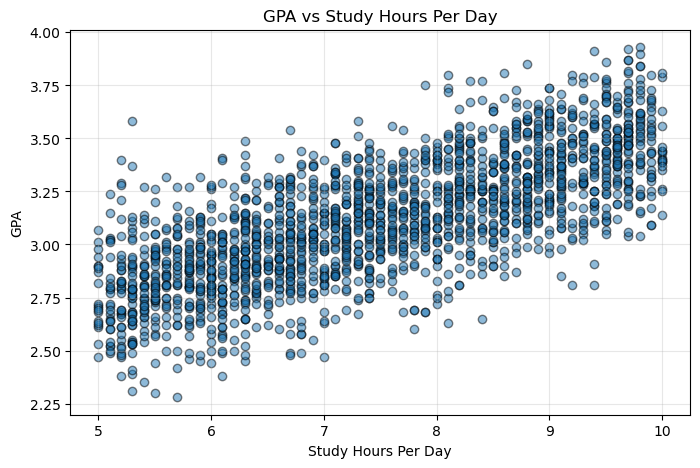

In [21]:
plot_relationship(data, 'Study_Hours_Per_Day', 'GPA', 
                  'GPA vs Study Hours Per Day', 'Study Hours Per Day', 'GPA')

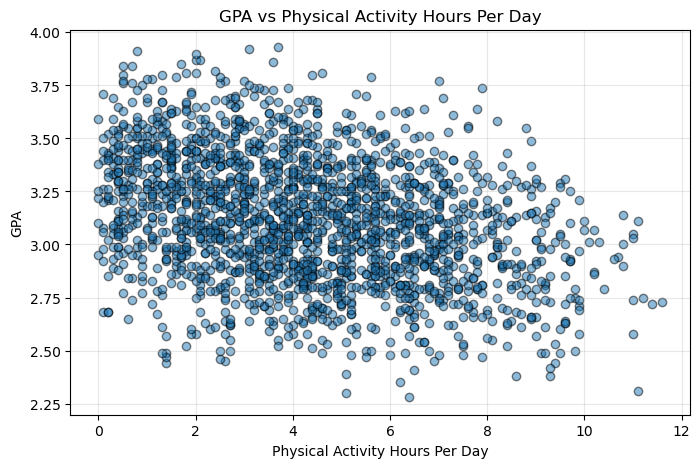

In [22]:
plot_relationship(data, 'Physical_Activity_Hours_Per_Day', 'GPA', 
                  'GPA vs Physical Activity Hours Per Day', 'Physical Activity Hours Per Day', 'GPA')

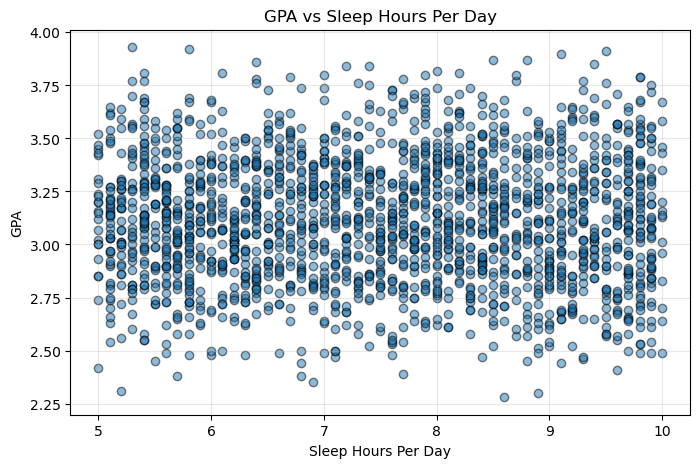

In [23]:
plot_relationship(data, 'Sleep_Hours_Per_Day', 'GPA', 
                  'GPA vs Sleep Hours Per Day', 'Sleep Hours Per Day', 'GPA')

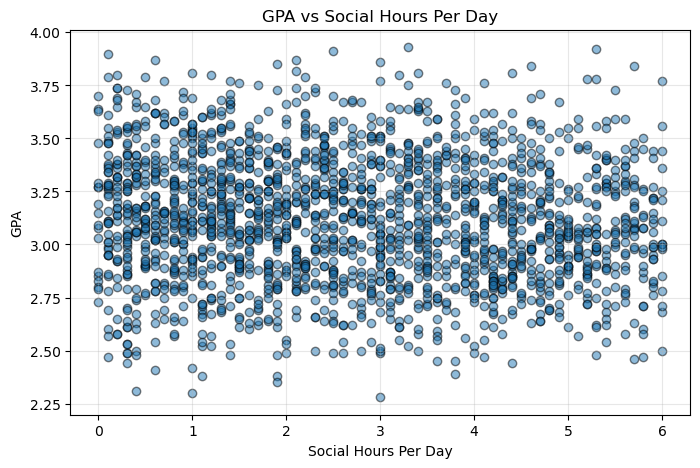

In [24]:
plot_relationship(data, 'Social_Hours_Per_Day', 'GPA', 
                  'GPA vs Social Hours Per Day', 'Social Hours Per Day', 'GPA')

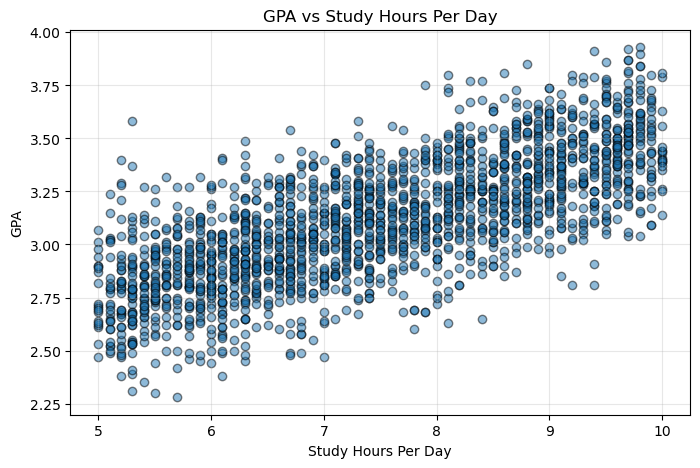

In [25]:
plot_relationship(data, 'Study_Hours_Per_Day', 'GPA', 
                  'GPA vs Study Hours Per Day', 'Study Hours Per Day', 'GPA')

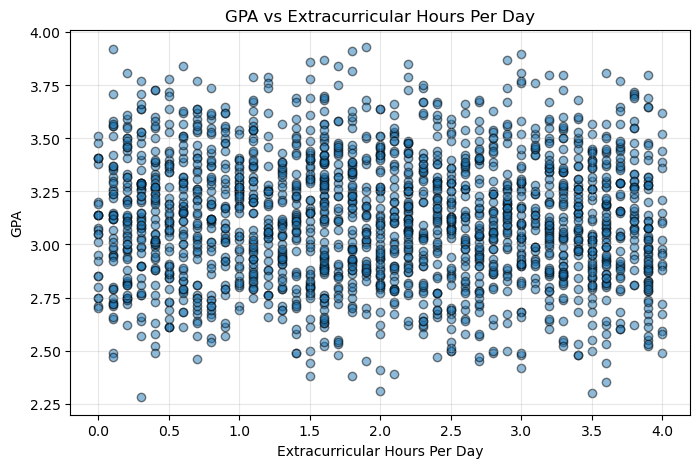

In [26]:
plot_relationship(data, 'Extracurricular_Hours_Per_Day', 'GPA', 
                  'GPA vs Extracurricular Hours Per Day', 'Extracurricular Hours Per Day', 'GPA')

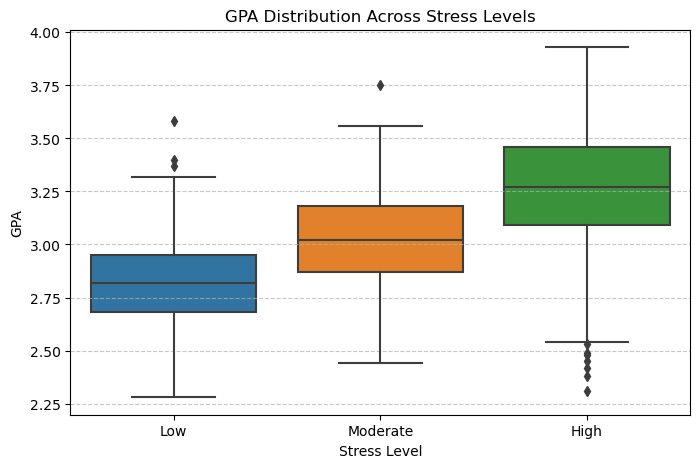

In [27]:
# Step 5: Analyze GPA across stress levels
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Stress_Level', y='GPA', order=['Low', 'Moderate', 'High'])
plt.title('GPA Distribution Across Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('GPA')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
# Average GPA by stress level
avg_gpa_stress = data.groupby('Stress_Level')['GPA'].mean()
print("\nAverage GPA by Stress Level:")
print(avg_gpa_stress)


Average GPA by Stress Level:
Stress_Level
High        3.261940
Low         2.825052
Moderate    3.024837
Name: GPA, dtype: float64


In [29]:
def plot_boxplot(data, x, y, title, xlabel, ylabel):
    """
    Plots a boxplot to analyze distributions of a variable across categories.

    Parameters:
    data (DataFrame): The dataset containing the columns.
    x (str): The column name for the categorical variable (e.g., 'Stress_Level').
    y (str): The column name for the numerical variable (e.g., 'Study_Hours_Per_Day').
    title (str): The title of the plot.
    xlabel (str): The label for the x-axis.
    ylabel (str): The label for the y-axis.
    """
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x=x, y=y, order=['Low', 'Moderate', 'High'])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


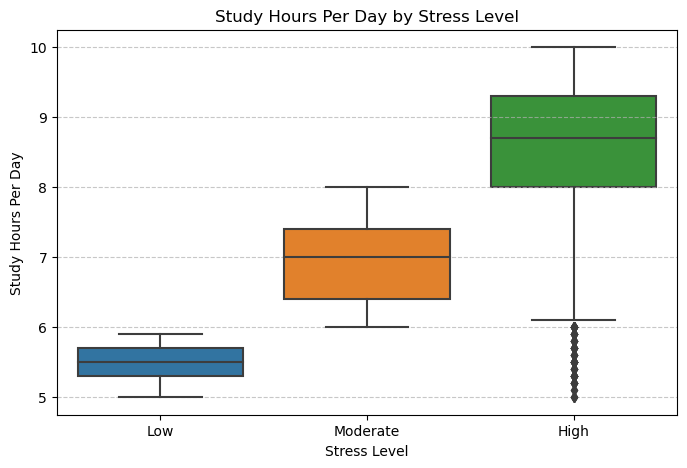

In [30]:
plot_boxplot(data, 'Stress_Level', 'Study_Hours_Per_Day', 
             'Study Hours Per Day by Stress Level', 'Stress Level', 'Study Hours Per Day')

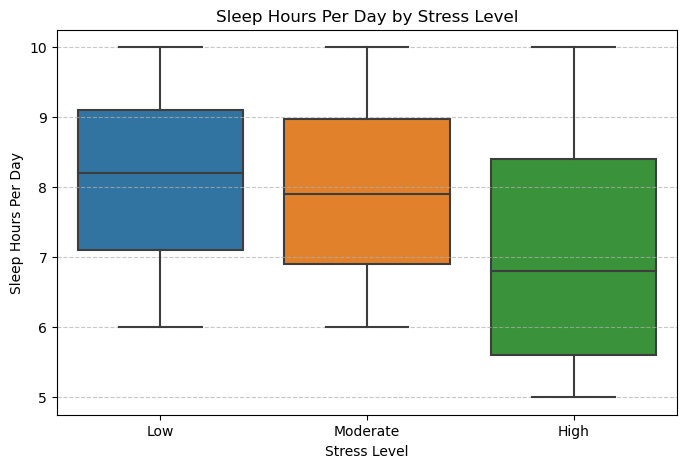

In [31]:
plot_boxplot(data, 'Stress_Level', 'Sleep_Hours_Per_Day', 
             'Sleep Hours Per Day by Stress Level', 'Stress Level', 'Sleep Hours Per Day')

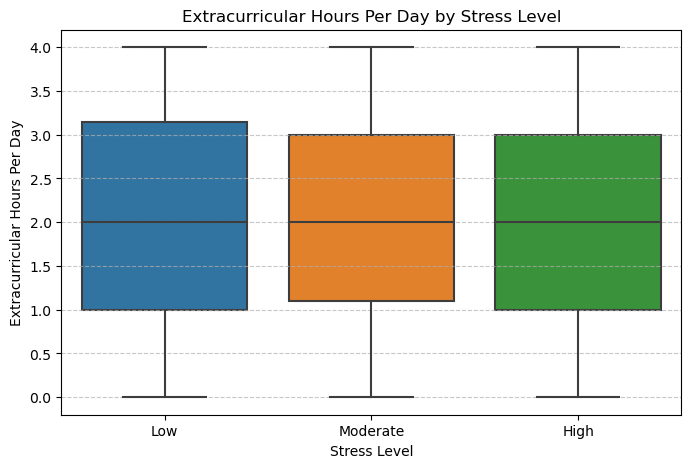

In [32]:
plot_boxplot(data, 'Stress_Level', 'Extracurricular_Hours_Per_Day', 
             'Extracurricular Hours Per Day by Stress Level', 'Stress Level', 'Extracurricular Hours Per Day')

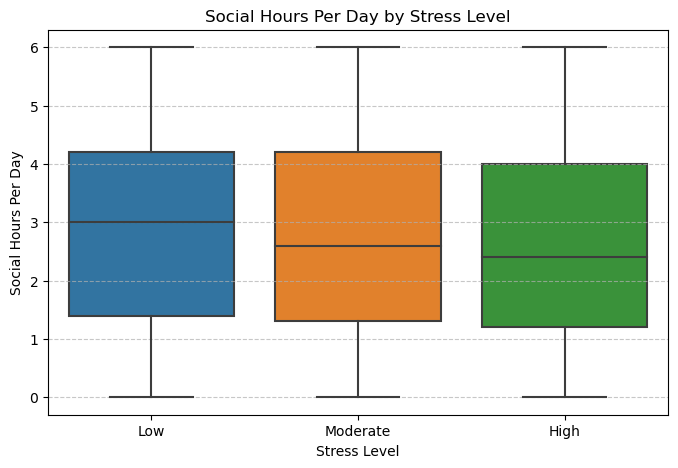

In [33]:
plot_boxplot(data, 'Stress_Level', 'Social_Hours_Per_Day', 
             'Social Hours Per Day by Stress Level', 'Stress Level', 'Social Hours Per Day')

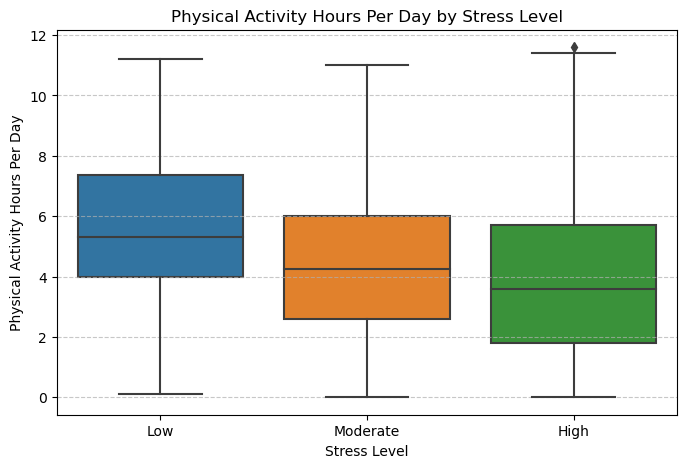

In [36]:
plot_boxplot(data, 'Stress_Level', 'Physical_Activity_Hours_Per_Day', 
             'Physical Activity Hours Per Day by Stress Level', 'Stress Level', 'Physical Activity Hours Per Day')

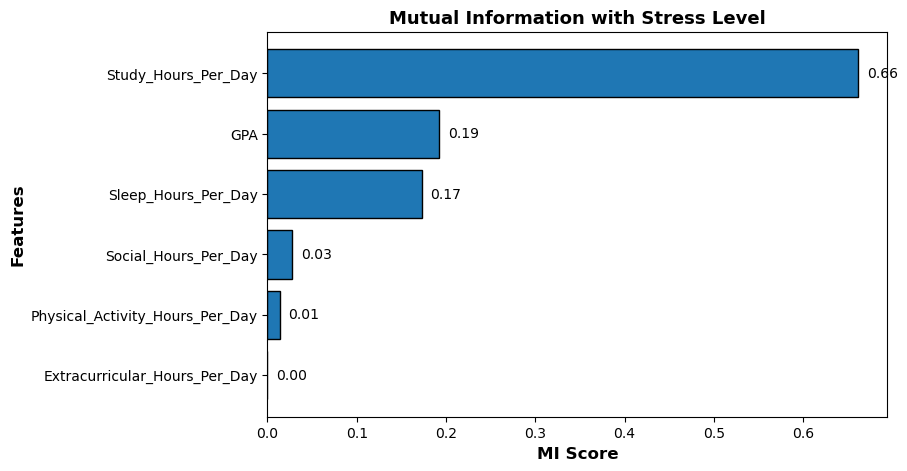

In [44]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

# Define SEED for reproducibility
SEED = 42

# Drop unnecessary columns and separate features and target
data_features = data.drop(['Student_ID', 'Stress_Level'], axis=1)
data_target = data['Stress_Level']

# Calculate Mutual Information (MI) scores
mi_scores = mutual_info_classif(X=data_features, y=data_target, random_state=SEED, discrete_features=False)

# Create a DataFrame to store MI scores
mi_data = pd.DataFrame({'Feature': data_features.columns, 'MI': mi_scores})

# Sort MI scores in ascending order
mi_data = mi_data.sort_values('MI', ascending=True, ignore_index=True)

# Plot the MI scores
plt.figure(figsize=(8, 5))
bars = plt.barh(mi_data['Feature'], mi_data['MI'], edgecolor='black')

# Add labels to each bar
for bar, score in zip(bars, mi_data['MI']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, 
             f'{score:.2f}', va='center', fontsize=10)

# Customize the plot
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xlabel('MI Score', fontsize=12, fontweight='bold')
plt.title('Mutual Information with Stress Level', fontsize=13, fontweight='bold')
plt.show()

# Predicting Stress Levels Using Random Forest


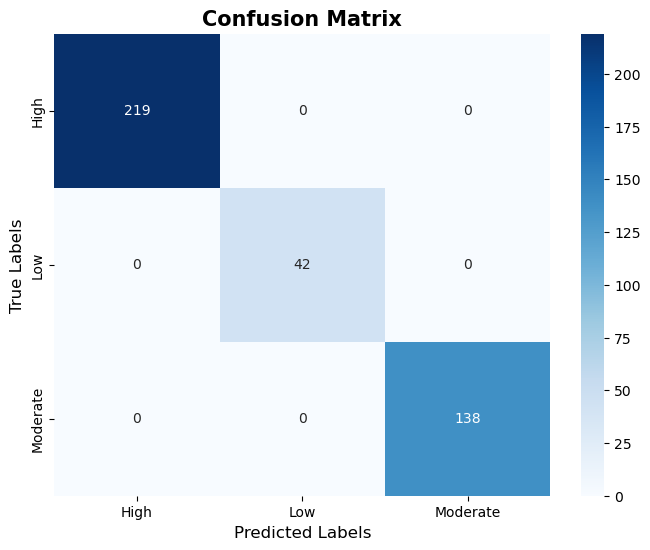

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       219
         Low       1.00      1.00      1.00        42
    Moderate       1.00      1.00      1.00       138

    accuracy                           1.00       399
   macro avg       1.00      1.00      1.00       399
weighted avg       1.00      1.00      1.00       399



In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Encode the target variable
le = LabelEncoder()
data['Stress_Level_Encoded'] = le.fit_transform(data['Stress_Level'])

# Prepare features and target
X = data.drop(['Student_ID', 'Stress_Level', 'Stress_Level_Encoded'], axis=1)
y = data['Stress_Level_Encoded']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
